# Data Preprocessing

## Setup

In [2]:
import build_data as data
from pathlib import Path
import pandas as pd
import shutil
from data_utils import stratified_train_test_split, equalize_test_data, create_domain_stratified_hdf5, get_transform, IMAGENET_NORM, add_image_variant_to_hdf5, delete_variant_datasets

In [3]:
RAW_DATASETS_DIR = Path('../../datasets').resolve()
PROJECT_DATA_DIR = Path('../data').resolve()
data.LABEL_COLS

['Vaccum Cleaning',
 'Mopping the Floor',
 'Carry Warm Food',
 'Carry Cold Food',
 'Carry Drinks',
 'Carry Small Objects',
 'Carry Large Objects',
 'Cleaning',
 'Starting a conversation']

## Preparing datasets for training.

In [ ]:
data.set_dataset_dir(RAW_DATASETS_DIR)
data.set_project_data_dir(PROJECT_DATA_DIR)
aggregated_data_path = data.main('mean_data', aggregate_data=True)
raw_data_path = data.main('all_data', aggregate_data=False)

Raw data from datasets processed.
Data from datasets saved under D:/projects/socialsense/data/raw_data.pkl.


In [ ]:
df = pd.read_pickle(aggregated_data_path)
df.head()

,Vaccum Cleaning,Mopping the Floor,Carry Warm Food,Carry Cold Food,Carry Drinks,Carry Small Objects,Carry Large Objects,Cleaning,Starting a conversation,dataset,domain,image_path,image_ref,robot
0,2.000000,2.333333,3.000000,3.666667,3.666667,4.000000,2.000000,2.666667,4.000000,MANNERSDBPlus,Home,D:\projects\datasets\MANNERSDBPlus\NAO\Images\...,0,NAO
1,3.000000,3.000000,3.000000,3.000000,3.000000,3.666667,3.333333,4.333333,3.000000,MANNERSDBPlus,Home,D:\projects\datasets\MANNERSDBPlus\NAO\Images\...,1000,NAO
2,2.000000,2.500000,1.500000,1.500000,1.500000,2.500000,1.750000,2.000000,1.500000,MANNERSDBPlus,Home,D:\projects\datasets\MANNERSDBPlus\NAO\Images\...,1001,NAO
3,3.333333,3.333333,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.333333,MANNERSDBPlus,Home,D:\projects\datasets\MANNERSDBPlus\NAO\Images\...,1002,NAO
4,3.000000,2.666667,2.666667,2.666667,2.666667,2.333333,2.666667,3.000000,2.333333,MANNERSDBPlus,Home,D:\projects\datasets\MANNERSDBPlus\NAO\Images\...,1003,NAO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,2.333333,2.333333,3.333333,3.333333,4.000000,3.333333,2.333333,2.333333,2.666667,OFFICE-MANNERSDB,SmallOffice,D:\projects\datasets\OFFICE-MANNERSDB\Pepper\I...,95,Pepper
5996,2.333333,2.333333,2.666667,3.666667,3.666667,3.666667,1.333333,3.333333,4.333333,OFFICE-MANNERSDB,SmallOffice,D:\projects\datasets\OFFICE-MANNERSDB\Pepper\I...,96,Pepper
5997,3.000000,3.333333,3.666667,3.666667,3.666667,3.666667,2.333333,3.666667,2.666667,OFFICE-MANNERSDB,SmallOffice,D:\projects\datasets\OFFICE-MANNERSDB\Pepper\I...,97,Pepper
5998,3.333333,3.666667,4.000000,4.000000,4.000000,4.000000,3.333333,4.666667,4.333333,OFFICE-MANNERSDB,SmallOffice,D:\projects\datasets\OFFICE-MANNERSDB\Pepper\I...,98,Pepper


In [13]:
# Update image_path with new subset paths
def update_image_paths(df, new_img_path, target_df_path):
    """
    Update image_path column to a new subset paths.
    """
    new_img_path = Path(new_img_path)
    df['image_path'] = df['image_path'].apply(
            lambda original_path: (new_img_path / Path(original_path).name).resolve().as_posix()
        )
    df.to_pickle(target_df_path)
    return df

def copy_images_to_dir(df: pd.DataFrame, dest_dir: Path) -> None:
    """
    Copy images referenced in df['image_path'] to dest_dir.
    """
    dest_dir.mkdir(parents=True, exist_ok=True)
    for src_path_str in df['image_path'].unique():
        src_path = Path(src_path_str)
        dst_path = dest_dir / src_path.name
        if not dst_path.exists():
            # print(f'copying image {src_path}')
            shutil.copy2(src_path, dst_path)

In [14]:
new_img_dir = PROJECT_DATA_DIR / 'images'
pepper_df = df[df['robot']=='Pepper'].copy().reset_index(drop=True)
# Cleanup columns
pepper_df = pepper_df[['image_path', 'domain'] + data.LABEL_COLS]
pepper_df = update_image_paths(pepper_df, new_img_dir, PROJECT_DATA_DIR / 'mean_data_pepper.pkl')

In [7]:
# Copy Pepper images to new dir
copy_images_to_dir(pepper_df, new_img_dir)

In [24]:
# Extract and save separately, 20% of the dataset as test set
train_path, test_path = stratified_train_test_split(dataframe_path=PROJECT_DATA_DIR / 'mean_data_pepper.pkl', seed=42)

In [25]:
test_df = pd.read_pickle(test_path)
img_count = test_df.groupby("domain")['image_path'].nunique()
img_count

domain
BigOffice-2     40
BigOffice-3     40
Hallway         40
Home           200
MeetingRoom     40
SmallOffice     40
Name: image_path, dtype: int64

In [26]:
# Equalise all domains to the smallest domain (samplewise) to avoid domain size bias during testing.
# And save as new dataframe
new_path = equalize_test_data(test_path, seed=42)
print(f"Equalized test dataframe saved under {new_path}")

Equalized test dataframe saved under D:\projects\socialsense\data\mean_data_pepper_test_equal.pkl


## Add columns for different images for different model versions

In [5]:
def sub_file_path(orig_path, new_root):
    new_path = Path(new_root) / Path(orig_path).name
    if not new_path.is_file():
        raise FileNotFoundError(new_path)
    return new_path.as_posix()

In [4]:
for path in [
    '../data/mean_data_pepper_train.pkl',
    '../data/mean_data_pepper_test.pkl',
    '../data/mean_data_pepper_test_equal.pkl'
    ]:
    df = pd.read_pickle(path)
    df['image_path_env'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/masked/environment'))
    df['image_path_env_elipses'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/masked/environment_elipses'))
    df['image_path_env_plus'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/masked/environment_plus'))
    df['image_path_env_boxes_plus'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/masked/environment_boxes_plus'))
    df['image_path_env_empty'] = df.apply(lambda row: Path(f"../data/empty_room/{row['domain']}.png"), axis=1)
    df['image_path_env_empty'].apply(lambda x: Path(x).is_file())
    df['image_path_soc'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/masked/social'))
    df.to_pickle(path)

In [ ]:
for path in [
    "../data/robotfocus_pepper_data_train.pkl",
    "../data/robotfocus_pepper_data_test.pkl",
    "../data/robotfocus_pepper_data_test_equal.pkl"
    ]:
    df = pd.read_pickle(path)
    df['image_path_scene'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/images_256x144'))
    df['image_path_focus_x1.5'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/robot_closeup_x1.5'))
    df['image_path_focus_x2'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/robot_closeup_x2'))
    df['image_path_focus_x3'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/robot_closeup_x3'))
    df['image_path_focus_x4'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/robot_closeup_x4'))
    df.to_pickle(path)

## Preprocess dataframes into shared HDF5

In [ ]:
ordered_domains = ['Home', 'BigOffice-2', 'BigOffice-3', 'Hallway', 'MeetingRoom', 'SmallOffice']
img_variant_columns = [
    'image_path',
    'image_path_env',
    'image_path_env_elipses',
    'image_path_env_plus',
    'image_path_env_empty',
    'image_path_soc'
    ]
variant_transforms = [
    get_transform((144,256), IMAGENET_NORM),
    get_transform((144,256), IMAGENET_NORM),
    get_transform((144,256), IMAGENET_NORM),
    get_transform((144,256), IMAGENET_NORM),
    get_transform((144,256), IMAGENET_NORM),
    get_transform((144,256), IMAGENET_NORM)
    ]
assert len(img_variant_columns) == len(variant_transforms)

create_domain_stratified_hdf5(
    hdf5_path= PROJECT_DATA_DIR / "mean_data_pepper.hdf5", 
    train_df= pd.read_pickle(PROJECT_DATA_DIR / 'mean_data_pepper_train.pkl'), 
    test_df= pd.read_pickle(PROJECT_DATA_DIR / 'mean_data_pepper_test.pkl'), 
    ordered_domains=ordered_domains, 
    img_path_cols=img_variant_columns, 
    transforms=variant_transforms, 
    seed=42
    )

SmallOffice/test/image_path_soc: 100%|██████████| 40/40 [00:01<00:00, 20.70it/s]


✅ HDF5 written at D:\projects\socialsense\data\mean_data_pepper.hdf5


True

In [4]:
ordered_domains = ['Home', 'BigOffice-2', 'BigOffice-3', 'Hallway', 'MeetingRoom', 'SmallOffice']
new_col = 'image_path_env_boxes_plus'
new_transform = get_transform((144, 256), IMAGENET_NORM)

add_image_variant_to_hdf5(
    hdf5_path=PROJECT_DATA_DIR / "mean_data_pepper.hdf5",
    train_df=pd.read_pickle(PROJECT_DATA_DIR / 'mean_data_pepper_train.pkl'),
    test_df=pd.read_pickle(PROJECT_DATA_DIR / 'mean_data_pepper_test.pkl'),
    ordered_domains=ordered_domains,
    new_img_col=new_col,
    new_transform=new_transform,
    seed=42
)


Adding Home/test/image_path_env_boxes_plus: 100%|██████████| 200/200 [00:01<00:00, 133.78it/s]
Adding BigOffice-2/train/image_path_env_boxes_plus: 100%|██████████| 120/120 [00:01<00:00, 98.77it/s]
Adding BigOffice-2/val/image_path_env_boxes_plus: 100%|██████████| 40/40 [00:00<00:00, 93.90it/s] 
Adding BigOffice-2/test/image_path_env_boxes_plus: 100%|██████████| 40/40 [00:00<00:00, 95.01it/s] 
Adding BigOffice-3/train/image_path_env_boxes_plus: 100%|██████████| 120/120 [00:01<00:00, 109.99it/s]
Adding BigOffice-3/val/image_path_env_boxes_plus: 100%|██████████| 40/40 [00:00<00:00, 120.85it/s]
Adding BigOffice-3/test/image_path_env_boxes_plus: 100%|██████████| 40/40 [00:00<00:00, 108.70it/s]
Adding Hallway/test/image_path_env_boxes_plus: 100%|██████████| 40/40 [00:00<00:00, 470.59it/s]
Adding MeetingRoom/train/image_path_env_boxes_plus: 100%|██████████| 120/120 [00:01<00:00, 102.13it/s]
Adding MeetingRoom/val/image_path_env_boxes_plus: 100%|██████████| 40/40 [00:00<00:00, 102.83it/s]
Addi

✅ Added image_path_env_boxes_plus to all domains/splits in D:\projects\socialsense\data\mean_data_pepper.hdf5


In [3]:
ordered_domains = ['Home', 'BigOffice-2', 'BigOffice-3', 'Hallway', 'MeetingRoom', 'SmallOffice']
delete_variant_datasets(
    hdf5_path=PROJECT_DATA_DIR / "mean_data_pepper.hdf5",
    variant_name='image_path_env_boxes_plus',
    ordered_domains=ordered_domains,
)

Deleting Home/train/images/image_path_env_boxes_plus
Deleting Home/val/images/image_path_env_boxes_plus
Deleting Home/test/images/image_path_env_boxes_plus
Deleting BigOffice-2/train/images/image_path_env_boxes_plus
Deleting BigOffice-2/val/images/image_path_env_boxes_plus
Deleting BigOffice-2/test/images/image_path_env_boxes_plus
Deleting BigOffice-3/train/images/image_path_env_boxes_plus
Deleting BigOffice-3/val/images/image_path_env_boxes_plus
Deleting BigOffice-3/test/images/image_path_env_boxes_plus
Deleting Hallway/train/images/image_path_env_boxes_plus
Deleting Hallway/val/images/image_path_env_boxes_plus
Deleting Hallway/test/images/image_path_env_boxes_plus
Deleting MeetingRoom/train/images/image_path_env_boxes_plus
Deleting MeetingRoom/val/images/image_path_env_boxes_plus
Deleting MeetingRoom/test/images/image_path_env_boxes_plus
Deleting SmallOffice/train/images/image_path_env_boxes_plus
Deleting SmallOffice/val/images/image_path_env_boxes_plus
Deleting SmallOffice/test/imag

#### Inspect if the standard vs hdf5 dataloaders produce same results

In [5]:
from data_utils import get_domain_dataloaders, get_domain_dataloaders_from_hdf5

img_path_cols = ['image_path_env', 'image_path_env_elipses', 'image_path_env_plus', 'image_path_env_boxes_plus']
transform_list = [get_transform((144,256), IMAGENET_NORM)]*4
d_labels = False
domains = ['Home', 'BigOffice-2', 'BigOffice-3', 'Hallway', 'MeetingRoom', 'SmallOffice']

In [6]:
hdf5_domain_dataloaders = get_domain_dataloaders_from_hdf5(
    hdf5_path="../data/mean_data_pepper.hdf5",
    domains=domains,
    img_path_cols=img_path_cols,
    set_first_element_as_domain_label=d_labels,
    num_workers=0
)

In [7]:
domain_dataloaders = get_domain_dataloaders(
    df = pd.read_pickle('../data/mean_data_pepper_train.pkl'), 
    seed=42, 
    batch_sizes=(32,64,64), 
    img_path_cols=img_path_cols, 
    transforms=transform_list, 
    num_workers=0,
    include_test= pd.read_pickle('../data/mean_data_pepper_test.pkl'), 
    set_first_element_as_domain_label=d_labels)

In [3]:
import matplotlib.pyplot as plt
import torch
import numpy as np

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denormalize(img_tensor: torch.Tensor) -> np.ndarray:
    """Reverse ImageNet normalization and convert tensor to uint8 HxWx3."""
    img_np = img_tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN
    img_np = torch.clamp(img_np, 0, 1)
    img_np = img_np.permute(1, 2, 0).numpy()
    return (img_np * 255).astype(np.uint8)

def inspect_dataloader(dataloaders, img_columns, domains,
                       example_indices=[0,5,10],
                       set_first_element_as_domain_label=False):
    """
    Generic visual inspection for either dataframe-based or HDF5 datasets.
    Displays images for specified batch indices (e.g. 0,5,10) in each domain/split.
    """
    for domain in domains:
        print(f"\n=== DOMAIN: {domain} ===")
        if domain not in dataloaders:
            print(f"Domain {domain} not in dataloaders dict.")
            continue

        for split, loader in dataloaders[domain].items():
            if split != 'test':
                continue
            try:
                batch = next(iter(loader))
            except StopIteration:
                print(f"No data in {domain}/{split}")
                continue

            # Unpack for PyTorch dataset returning tuple
            if isinstance(batch, (list, tuple)) and len(batch) == 3:
                inputs, labels, dom_indexes = batch
            elif isinstance(batch, (list, tuple)) and len(batch) == 2:
                inputs, labels = batch
                dom_indexes = None
            else:
                inputs = batch
                labels, dom_indexes = None, None

            # Remove first element if it's a domain label (+images)
            if set_first_element_as_domain_label and isinstance(inputs, (tuple, list)):
                inputs = inputs[1:]

            # When dataset returns a single image tensor per batch, normalize format
            if isinstance(inputs, torch.Tensor):
                inputs = (inputs,)

            batch_size = inputs[0].shape[0]

            # Iterate through example indices
            for idx in example_indices:
                if idx >= batch_size:
                    continue

                print(f"   {split} example index: {idx}")
                fig, axes = plt.subplots(1, len(inputs), figsize=(5*len(inputs), 4))
                if len(inputs) == 1:
                    axes = [axes]

                for i, img_batch in enumerate(inputs):
                    img_t = img_batch[idx]
                    img_np = denormalize(img_t)
                    axes[i].imshow(img_np)
                    label_str = f"Label: {labels[idx].numpy()}" if labels is not None else ""
                    dom_str = f"Domain ID: {dom_indexes[idx].item()}" if dom_indexes is not None else ""
                    axes[i].set_title(f"{img_columns[i]}\n{label_str}\n{dom_str}")
                    axes[i].axis('off')

                plt.tight_layout()
                plt.show()




=== DOMAIN: Hallway ===
   test example index: 4


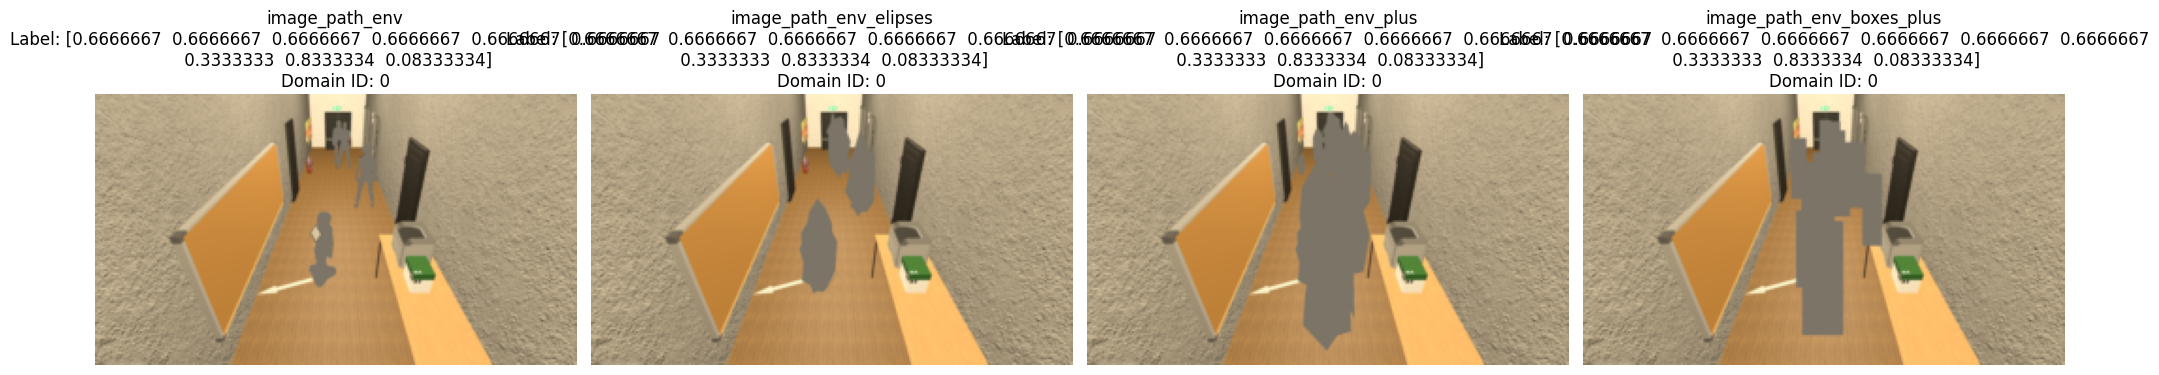

In [9]:
inspect_dataloader(
    domain_dataloaders,
    img_columns=img_path_cols,
    domains=['Hallway'],
    example_indices=[4],
    set_first_element_as_domain_label=d_labels
)



=== DOMAIN: Hallway ===
   test example index: 4


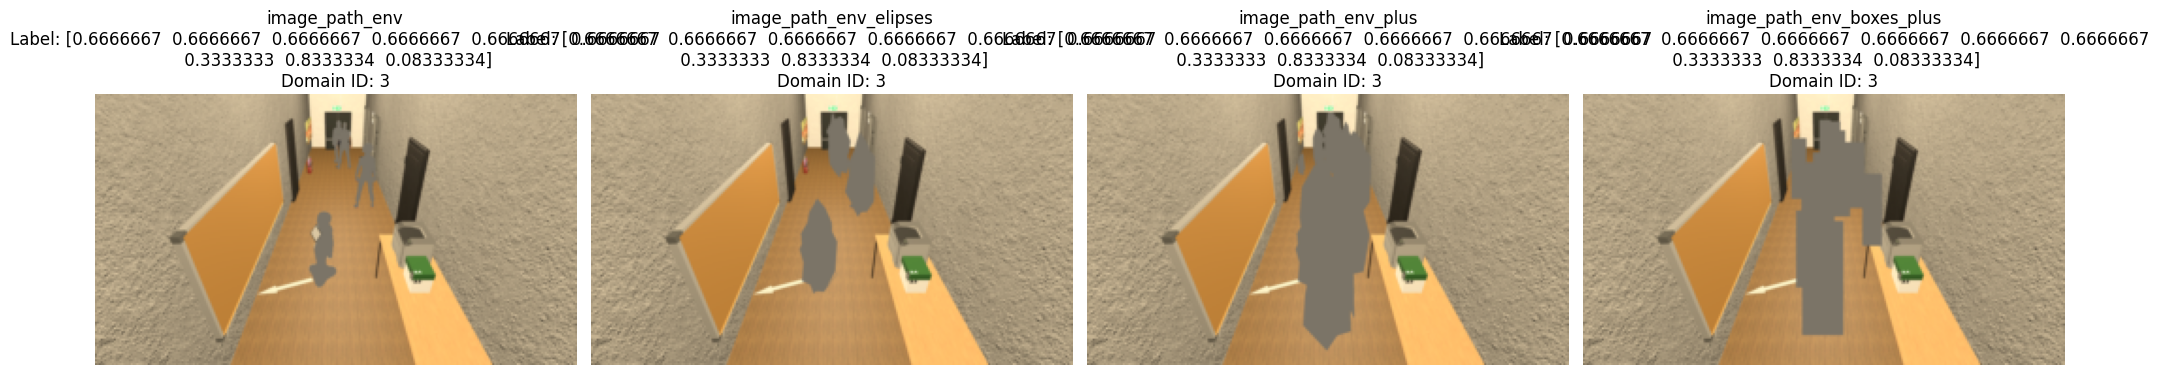

In [10]:
inspect_dataloader(
    hdf5_domain_dataloaders,
    img_columns=img_path_cols,
    domains=['Hallway'],
    example_indices=[4],
    set_first_element_as_domain_label=d_labels
)


In [19]:
import h5py

def print_hdf5_structure(name, obj, prefix=""):
    if isinstance(obj, h5py.Group):
        items = len(obj)
        for key, val in obj.items():
            items -= 1
            if items == 0:  # last item
                print(f"{prefix}└── {key}/")
                print_hdf5_structure(name, val, prefix + "    ")
            else:
                print(f"{prefix}├── {key}/")
                print_hdf5_structure(name, val, prefix + "│   ")
    else:
        shape = obj.shape if hasattr(obj, 'shape') else 'scalar'
        print(f"{prefix}├── {name} {shape}")

with h5py.File("../data/robotfocus128_pepper_data.hdf5", 'r') as f:
    print_hdf5_structure('/', f)


├── BigOffice-2/
│   ├── test/
│   │   ├── images/
│   │   │   ├── image_path_focus_x1.5/
│   │   │   │   ├── / (149, 3, 128, 128)
│   │   │   ├── image_path_focus_x2/
│   │   │   │   ├── / (149, 3, 128, 128)
│   │   │   ├── image_path_focus_x4/
│   │   │   │   ├── / (149, 3, 128, 128)
│   │   │   └── image_path_scene/
│   │   │       ├── / (149, 3, 144, 256)
│   │   └── labels/
│   │       ├── / (149, 9)
│   ├── train/
│   │   ├── images/
│   │   │   ├── image_path_focus_x1.5/
│   │   │   │   ├── / (111, 3, 128, 128)
│   │   │   ├── image_path_focus_x2/
│   │   │   │   ├── / (111, 3, 128, 128)
│   │   │   ├── image_path_focus_x4/
│   │   │   │   ├── / (111, 3, 128, 128)
│   │   │   └── image_path_scene/
│   │   │       ├── / (111, 3, 144, 256)
│   │   └── labels/
│   │       ├── / (111, 9)
│   └── val/
│       ├── images/
│       │   ├── image_path_focus_x1.5/
│       │   │   ├── / (38, 3, 128, 128)
│       │   ├── image_path_focus_x2/
│       │   │   ├── / (38, 3, 128, 128)
│       │

### Create 5 fold cross validation hdf5 datasets

In [4]:
df = pd.read_pickle(PROJECT_DATA_DIR / 'mean_data_pepper.pkl')
df['image_path_env'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/masked/environment'))
df['image_path_env_elipses'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/masked/environment_elipses'))
df['image_path_env_plus'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/masked/environment_plus'))
df['image_path_env_boxes_plus'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/masked/environment_boxes_plus'))
df['image_path_env_empty'] = df.apply(lambda row: Path(f"../data/empty_room/{row['domain']}.png"), axis=1)
df['image_path_env_empty'].apply(lambda x: Path(x).is_file())
df['image_path_soc'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/masked/social'))
df

,image_path,domain,Vaccum Cleaning,Mopping the Floor,Carry Warm Food,Carry Cold Food,Carry Drinks,Carry Small Objects,Carry Large Objects,Cleaning,Starting a conversation,image_path_env,image_path_env_elipses,image_path_env_plus,image_path_env_boxes_plus,image_path_env_empty,image_path_soc
0,D:/projects/socialsense/data/images/0_1_0_4_0_...,Home,2.000000,1.666667,2.666667,2.666667,2.666667,3.000000,2.333333,3.333333,2.666667,../data/masked/environment/0_1_0_4_0_50_50_0_0...,../data/masked/environment_elipses/0_1_0_4_0_5...,../data/masked/environment_plus/0_1_0_4_0_50_5...,../data/masked/environment_boxes_plus/0_1_0_4_...,..\data\empty_room\Home.png,../data/masked/social/0_1_0_4_0_50_50_0_0_2.12...
1,D:/projects/socialsense/data/images/100_1_0_4_...,Home,2.333333,1.000000,2.333333,2.666667,2.666667,2.333333,1.000000,3.666667,3.333333,../data/masked/environment/100_1_0_4_0_50_50_1...,../data/masked/environment_elipses/100_1_0_4_0...,../data/masked/environment_plus/100_1_0_4_0_50...,../data/masked/environment_boxes_plus/100_1_0_...,..\data\empty_room\Home.png,../data/masked/social/100_1_0_4_0_50_50_1_0_2....
2,D:/projects/socialsense/data/images/101_1_0_5_...,Home,2.000000,2.000000,2.666667,3.000000,3.333333,3.666667,1.333333,3.000000,4.333333,../data/masked/environment/101_1_0_5_0_50_50_1...,../data/masked/environment_elipses/101_1_0_5_0...,../data/masked/environment_plus/101_1_0_5_0_50...,../data/masked/environment_boxes_plus/101_1_0_...,..\data\empty_room\Home.png,../data/masked/social/101_1_0_5_0_50_50_1_0_2....
3,D:/projects/socialsense/data/images/102_1_0_5_...,Home,2.333333,2.333333,2.333333,2.333333,2.333333,3.000000,2.333333,3.333333,2.666667,../data/masked/environment/102_1_0_5_0_50_50_1...,../data/masked/environment_elipses/102_1_0_5_0...,../data/masked/environment_plus/102_1_0_5_0_50...,../data/masked/environment_boxes_plus/102_1_0_...,..\data\empty_room\Home.png,../data/masked/social/102_1_0_5_0_50_50_1_0_0....
4,D:/projects/socialsense/data/images/103_1_0_8_...,Home,1.500000,1.500000,4.000000,4.500000,4.500000,3.750000,1.750000,1.750000,3.750000,../data/masked/environment/103_1_0_8_5_0.86609...,../data/masked/environment_elipses/103_1_0_8_5...,../data/masked/environment_plus/103_1_0_8_5_0....,../data/masked/environment_boxes_plus/103_1_0_...,..\data\empty_room\Home.png,../data/masked/social/103_1_0_8_5_0.8660979_0_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,D:/projects/socialsense/data/images/SmallOffic...,SmallOffice,2.333333,2.333333,3.333333,3.333333,4.000000,3.333333,2.333333,2.333333,2.666667,../data/masked/environment/SmallOffice_95.png,../data/masked/environment_elipses/SmallOffice...,../data/masked/environment_plus/SmallOffice_95...,../data/masked/environment_boxes_plus/SmallOff...,..\data\empty_room\SmallOffice.png,../data/masked/social/SmallOffice_95.png
1996,D:/projects/socialsense/data/images/SmallOffic...,SmallOffice,2.333333,2.333333,2.666667,3.666667,3.666667,3.666667,1.333333,3.333333,4.333333,../data/masked/environment/SmallOffice_96.png,../data/masked/environment_elipses/SmallOffice...,../data/masked/environment_plus/SmallOffice_96...,../data/masked/environment_boxes_plus/SmallOff...,..\data\empty_room\SmallOffice.png,../data/masked/social/SmallOffice_96.png
1997,D:/projects/socialsense/data/images/SmallOffic...,SmallOffice,3.000000,3.333333,3.666667,3.666667,3.666667,3.666667,2.333333,3.666667,2.666667,../data/masked/environment/SmallOffice_97.png,../data/masked/environment_elipses/SmallOffice...,../data/masked/environment_plus/SmallOffice_97...,../data/masked/environment_boxes_plus/SmallOff...,..\data\empty_room\SmallOffice.png,../data/masked/social/SmallOffice_97.png
1998,D:/projects/socialsense/data/images/SmallOffic...,SmallOffice,3.333333,3.666667,4.000000,4.000000,4.000000,4.000000,3.333333,4.666667,4.333333,../data/masked/environment/SmallOffice_98.png,../data/masked/environment_elipses/SmallOffice...,../data/masked/environment_plus/SmallOffice_98...,../

In [5]:
# Preprocess dataframes into shared HDF5
ordered_domains = ['Home', 'BigOffice-2', 'BigOffice-3', 'Hallway', 'MeetingRoom', 'SmallOffice']
img_variant_columns = [
    'image_path',
    'image_path_env',
    'image_path_env_elipses',
    'image_path_env_plus',
    'image_path_env_boxes_plus',
    'image_path_env_empty',
    'image_path_soc'
    ]
variant_transforms = [
    get_transform((144,256), IMAGENET_NORM),
    get_transform((144,256), IMAGENET_NORM),
    get_transform((144,256), IMAGENET_NORM),
    get_transform((144,256), IMAGENET_NORM),
    get_transform((144,256), IMAGENET_NORM),
    get_transform((144,256), IMAGENET_NORM),
    get_transform((144,256), IMAGENET_NORM),
    ]
assert len(img_variant_columns) == len(variant_transforms)

In [6]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_loaders = {}

# Loop over each fold
for fold_num, (train_val_idx, test_idx) in enumerate(skf.split(df, df['domain'])):
    train_val_df = df.iloc[train_val_idx]
    test_df = df.iloc[test_idx]

    create_domain_stratified_hdf5(
        hdf5_path= PROJECT_DATA_DIR / f"mean_data_pepper_fold{fold_num}.hdf5", 
        train_df= train_val_df, 
        test_df= test_df, 
        ordered_domains=ordered_domains, 
        img_path_cols=img_variant_columns, 
        transforms=variant_transforms, 
        seed=42
        )

SmallOffice/test/image_path_soc: 100%|██████████| 40/40 [00:01<00:00, 20.77it/s]


✅ HDF5 written at D:\projects\socialsense\data\mean_data_pepper_fold0.hdf5


SmallOffice/test/image_path_soc: 100%|██████████| 40/40 [00:01<00:00, 27.42it/s]


✅ HDF5 written at D:\projects\socialsense\data\mean_data_pepper_fold1.hdf5


SmallOffice/test/image_path_soc: 100%|██████████| 40/40 [00:01<00:00, 29.54it/s]


✅ HDF5 written at D:\projects\socialsense\data\mean_data_pepper_fold2.hdf5


SmallOffice/test/image_path_soc: 100%|██████████| 40/40 [00:01<00:00, 29.26it/s]


✅ HDF5 written at D:\projects\socialsense\data\mean_data_pepper_fold3.hdf5


SmallOffice/test/image_path_soc: 100%|██████████| 40/40 [00:01<00:00, 30.56it/s]


✅ HDF5 written at D:\projects\socialsense\data\mean_data_pepper_fold4.hdf5


## Preprocess robotfocus dataset in the same way

In [ ]:
ordered_domains = ['Home', 'BigOffice-2', 'BigOffice-3', 'Hallway', 'MeetingRoom', 'SmallOffice']
img_variant_columns = [
    'image_path_scene',
    'image_path_focus_x1.5',
    'image_path_focus_x2',
    'image_path_focus_x4',
]
variant_transforms = [
    get_transform((144,256), IMAGENET_NORM),
    get_transform((128,128), IMAGENET_NORM),
    get_transform((128,128), IMAGENET_NORM),
    get_transform((128,128), IMAGENET_NORM),
    ]
assert len(img_variant_columns) == len(variant_transforms)

create_domain_stratified_hdf5(
    hdf5_path= PROJECT_DATA_DIR / "robotfocus128_pepper_data.hdf5", 
    train_df= pd.read_pickle(PROJECT_DATA_DIR / 'robotfocus_pepper_data_train.pkl'), 
    test_df= pd.read_pickle(PROJECT_DATA_DIR / 'robotfocus_pepper_data_test.pkl'), 
    ordered_domains=ordered_domains, 
    img_path_cols=img_variant_columns, 
    transforms=variant_transforms, 
    seed=42
    )

SmallOffice/test/image_path_focus_x4: 100%|██████████| 24/24 [00:00<00:00, 81.08it/s]


✅ HDF5 written at D:\projects\socialsense\data\robotfocus128_pepper_data.hdf5


True

In [10]:
ordered_domains = ['Home', 'BigOffice-2', 'BigOffice-3', 'Hallway', 'MeetingRoom', 'SmallOffice']
img_variant_columns = [
    'image_path_scene',
    'image_path_focus_x1.5',
    'image_path_focus_x2',
    'image_path_focus_x4',
]
variant_transforms = [
    get_transform((144,256), IMAGENET_NORM),
    get_transform((512,512), IMAGENET_NORM),
    get_transform((512,512), IMAGENET_NORM),
    get_transform((512,512), IMAGENET_NORM),
    ]
assert len(img_variant_columns) == len(variant_transforms)

create_domain_stratified_hdf5(
    hdf5_path= PROJECT_DATA_DIR / "robotfocus512_pepper_data.hdf5", 
    train_df= pd.read_pickle(PROJECT_DATA_DIR / 'robotfocus_pepper_data_train.pkl'), 
    test_df= pd.read_pickle(PROJECT_DATA_DIR / 'robotfocus_pepper_data_test.pkl'), 
    ordered_domains=ordered_domains, 
    img_path_cols=img_variant_columns, 
    transforms=variant_transforms, 
    seed=42
    )

SmallOffice/test/image_path_focus_x4: 100%|██████████| 24/24 [00:00<00:00, 72.51it/s]


✅ HDF5 written at D:\projects\socialsense\data\robotfocus512_pepper_data.hdf5


True

In [5]:
from data_utils import get_domain_dataloaders, get_domain_dataloaders_from_hdf5

img_path_cols = [
    'image_path_scene',
    'image_path_focus_x1.5',
    'image_path_focus_x2',
    'image_path_focus_x4',
]
transform_list = [
    get_transform((144,256), IMAGENET_NORM),
    get_transform((128,128), IMAGENET_NORM),
    get_transform((128,128), IMAGENET_NORM),
    get_transform((128,128), IMAGENET_NORM),
    ]
d_labels = False
domains = ['Home', 'BigOffice-2', 'BigOffice-3', 'Hallway', 'MeetingRoom', 'SmallOffice']

In [6]:
hdf5_domain_dataloaders = get_domain_dataloaders_from_hdf5(
    hdf5_path="../data/robotfocus128_pepper_data.hdf5",
    domains=domains,
    img_path_cols=img_path_cols,
    set_first_element_as_domain_label=d_labels,
    num_workers=0
)

In [7]:
domain_dataloaders = get_domain_dataloaders(
    df = pd.read_pickle('../data/robotfocus_pepper_data_train.pkl'), 
    seed=42, 
    batch_sizes=(32,64,64), 
    img_path_cols=img_path_cols, 
    transforms=transform_list, 
    num_workers=0,
    include_test= pd.read_pickle('../data/robotfocus_pepper_data_test.pkl'), 
    set_first_element_as_domain_label=d_labels)


=== DOMAIN: Hallway ===
   test example index: 5


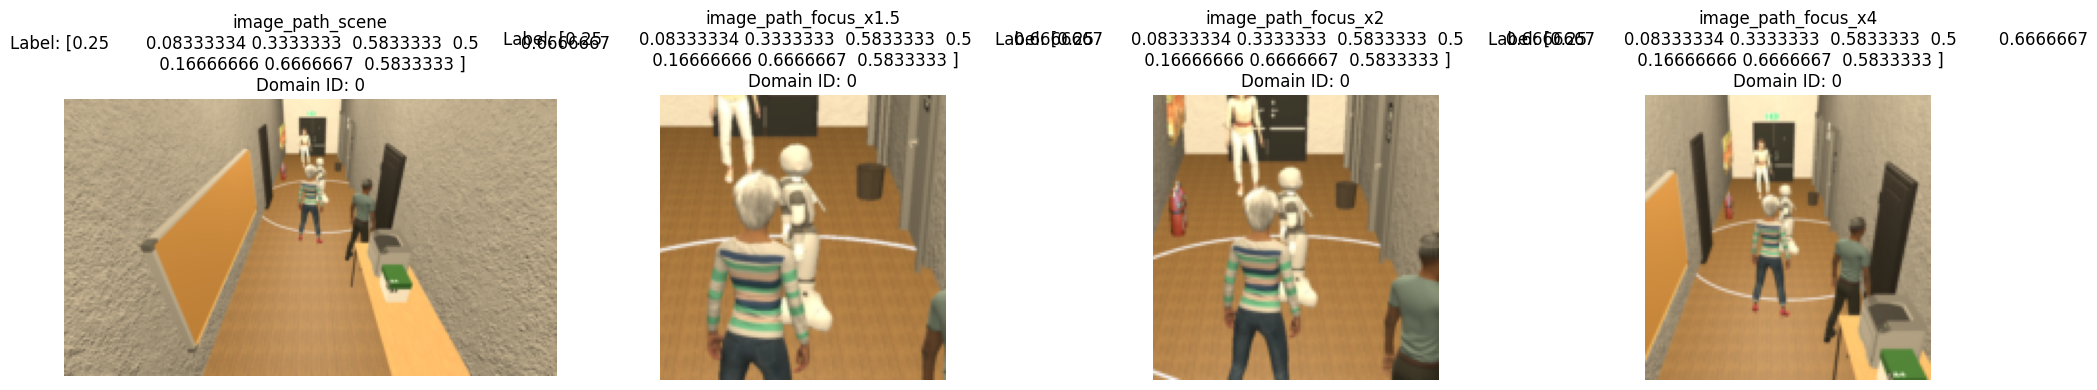

In [8]:
inspect_dataloader(
    domain_dataloaders,
    img_columns=img_path_cols,
    domains=['Hallway'],
    example_indices=[5],
    set_first_element_as_domain_label=d_labels
)



=== DOMAIN: Hallway ===
   test example index: 5


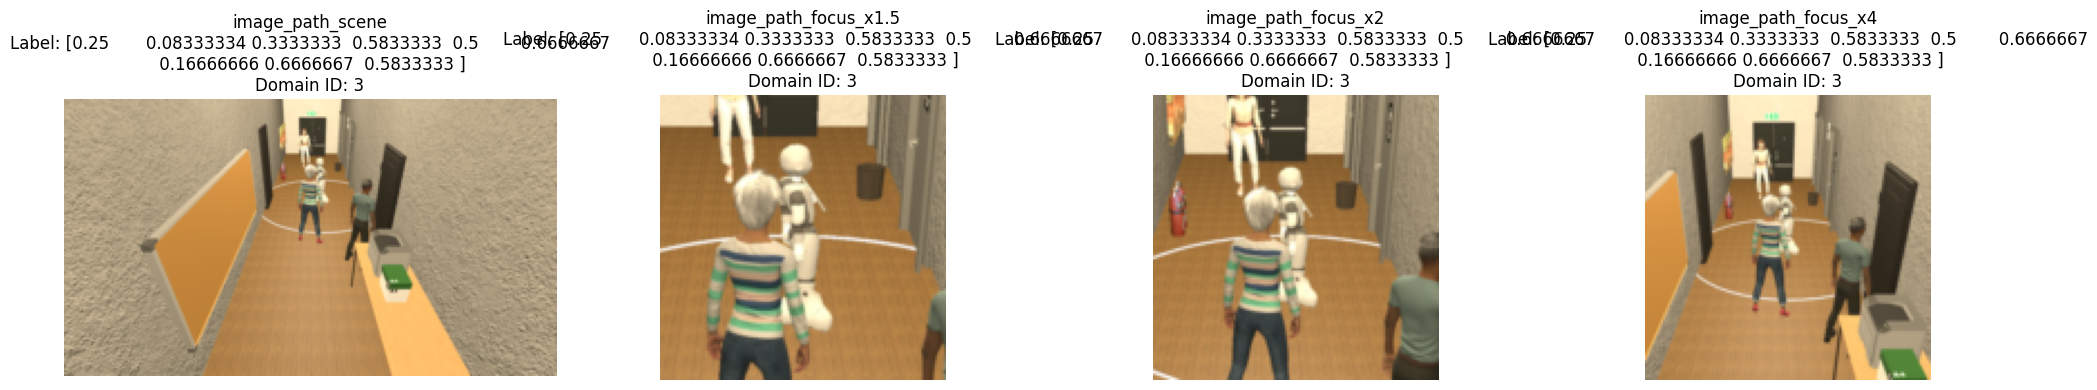

In [9]:
inspect_dataloader(
    hdf5_domain_dataloaders,
    img_columns=img_path_cols,
    domains=['Hallway'],
    example_indices=[5],
    set_first_element_as_domain_label=d_labels
)


In [ ]:
import h5py

def print_hdf5_structure(name, obj, prefix=""):
    if isinstance(obj, h5py.Group):
        items = len(obj)
        for key, val in obj.items():
            items -= 1
            if items == 0:  # last item
                print(f"{prefix}└── {key}/")
                print_hdf5_structure(name, val, prefix + "    ")
            else:
                print(f"{prefix}├── {key}/")
                print_hdf5_structure(name, val, prefix + "│   ")
    else:
        shape = obj.shape if hasattr(obj, 'shape') else 'scalar'
        print(f"{prefix}├── {name} {shape}")

with h5py.File("../data/mean_data_pepper.hdf5", 'r') as f:
    print_hdf5_structure('/', f)


├── BigOffice-2/
│   ├── test/
│   │   ├── images/
│   │   │   ├── image_path/
│   │   │   │   ├── / (40, 3, 144, 256)
│   │   │   ├── image_path_env/
│   │   │   │   ├── / (40, 3, 144, 256)
│   │   │   ├── image_path_env_boxes_plus/
│   │   │   │   ├── / (40, 3, 144, 256)
│   │   │   ├── image_path_env_elipses/
│   │   │   │   ├── / (40, 3, 144, 256)
│   │   │   ├── image_path_env_empty/
│   │   │   │   ├── / (40, 3, 144, 256)
│   │   │   ├── image_path_env_plus/
│   │   │   │   ├── / (40, 3, 144, 256)
│   │   │   └── image_path_soc/
│   │   │       ├── / (40, 3, 144, 256)
│   │   └── labels/
│   │       ├── / (40, 9)
│   ├── train/
│   │   ├── images/
│   │   │   ├── image_path/
│   │   │   │   ├── / (120, 3, 144, 256)
│   │   │   ├── image_path_env/
│   │   │   │   ├── / (120, 3, 144, 256)
│   │   │   ├── image_path_env_boxes_plus/
│   │   │   │   ├── / (120, 3, 144, 256)
│   │   │   ├── image_path_env_elipses/
│   │   │   │   ├── / (120, 3, 144, 256)
│   │   │   ├── image_path_env_

### 5 folds

In [6]:
df = pd.read_pickle("../data/robotfocus_pepper_data.pkl")
df['image_path_scene'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/images_256x144'))
df['image_path_focus_x1.5'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/robot_closeup_x1.5'))
df['image_path_focus_x2'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/robot_closeup_x2'))
df['image_path_focus_x3'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/robot_closeup_x3'))
df['image_path_focus_x4'] = df['image_path'].apply(lambda x: sub_file_path(x, new_root='../data/robot_closeup_x4'))
df

,image_path,domain,Vaccum Cleaning,Mopping the Floor,Carry Warm Food,Carry Cold Food,Carry Drinks,Carry Small Objects,Carry Large Objects,Cleaning,Starting a conversation,image_path_scene,image_path_focus_x1.5,image_path_focus_x2,image_path_focus_x3,image_path_focus_x4
4,D:/projects/socialsense/data/images/103_1_0_8_...,Home,1.500000,1.500000,4.000000,4.500000,4.500000,3.750000,1.750000,1.750000,3.750000,../data/images_256x144/103_1_0_8_5_0.8660979_0...,../data/robot_closeup_x1.5/103_1_0_8_5_0.86609...,../data/robot_closeup_x2/103_1_0_8_5_0.8660979...,../data/robot_closeup_x3/103_1_0_8_5_0.8660979...,../data/robot_closeup_x4/103_1_0_8_5_0.8660979...
7,D:/projects/socialsense/data/images/106_1_0_3_...,Home,2.333333,2.333333,4.000000,4.000000,4.000000,4.000000,2.000000,4.000000,2.333333,../data/images_256x144/106_1_0_3_0_50_50_0_0_2...,../data/robot_closeup_x1.5/106_1_0_3_0_50_50_0...,../data/robot_closeup_x2/106_1_0_3_0_50_50_0_0...,../data/robot_closeup_x3/106_1_0_3_0_50_50_0_0...,../data/robot_closeup_x4/106_1_0_3_0_50_50_0_0...
8,D:/projects/socialsense/data/images/107_1_0_4_...,Home,2.333333,2.333333,3.666667,3.666667,3.666667,3.666667,1.666667,4.333333,2.333333,../data/images_256x144/107_1_0_4_0_50_50_0_0_2...,../data/robot_closeup_x1.5/107_1_0_4_0_50_50_0...,../data/robot_closeup_x2/107_1_0_4_0_50_50_0_0...,../data/robot_closeup_x3/107_1_0_4_0_50_50_0_0...,../data/robot_closeup_x4/107_1_0_4_0_50_50_0_0...
9,D:/projects/socialsense/data/images/108_1_0_3_...,Home,2.333333,2.333333,3.666667,3.666667,3.666667,4.000000,2.666667,4.333333,2.666667,../data/images_256x144/108_1_0_3_0_50_50_0_0_1...,../data/robot_closeup_x1.5/108_1_0_3_0_50_50_0...,../data/robot_closeup_x2/108_1_0_3_0_50_50_0_0...,../data/robot_closeup_x3/108_1_0_3_0_50_50_0_0...,../data/robot_closeup_x4/108_1_0_3_0_50_50_0_0...
10,D:/projects/socialsense/data/images/109_1_0_4_...,Home,1.333333,1.333333,2.666667,2.666667,2.666667,2.666667,2.666667,2.333333,4.000000,../data/images_256x144/109_1_0_4_0_50_50_0_0_0...,../data/robot_closeup_x1.5/109_1_0_4_0_50_50_0...,../data/robot_closeup_x2/109_1_0_4_0_50_50_0_0...,../data/robot_closeup_x3/109_1_0_4_0_50_50_0_0...,../data/robot_closeup_x4/109_1_0_4_0_50_50_0_0...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,D:/projects/socialsense/data/images/SmallOffic...,SmallOffice,2.666667,2.333333,3.000000,3.333333,3.000000,3.666667,2.000000,3.333333,4.333333,../data/images_256x144/SmallOffice_93.png,../data/robot_closeup_x1.5/SmallOffice_93.png,../data/robot_closeup_x2/SmallOffice_93.png,../data/robot_closeup_x3/SmallOffice_93.png,../data/robot_closeup_x4/SmallOffice_93.png
1994,D:/projects/socialsense/data/images/SmallOffic...,SmallOffice,3.000000,3.000000,3.250000,3.750000,3.750000,3.750000,2.000000,3.750000,4.000000,../data/images_256x144/SmallOffice_94.png,../data/robot_closeup_x1.5/SmallOffice_94.png,../data/robot_closeup_x2/SmallOffice_94.png,../data/robot_closeup_x3/SmallOffice_94.png,../data/robot_closeup_x4/SmallOffice_94.png
1997,D:/projects/socialsense/data/images/SmallOffic...,SmallOffice,3.000000,3.333333,3.666667,3.666667,3.666667,3.666667,2.333333,3.666667,2.666667,../data/images_256x144/SmallOffice_97.png,../data/robot_closeup_x1.5/SmallOffice_97.png,../data/robot_closeup_x2/SmallOffice_97.png,../data/robot_closeup_x3/SmallOffice_97.png,../data/robot_closeup_x4/SmallOffice_97.png
1998,D:/projects/socialsense/data/images/SmallOffic...,SmallOffice,3.333333,3.666667,4.000000,4.000000,4.000000,4.000000,3.333333,4.666667,4.333333,../data/images_256x144/SmallOffice_98.png,../data/robot_closeup_x1.5/SmallOffice_98.png,../data/robot_closeup_x2/SmallOffice_98.png,../data/robot_closeup_x3/SmallOffice_98.png,../data/robot_closeup_x4/SmallOffice_98.png


In [7]:
# Preprocess dataframes into shared HDF5
ordered_domains = ['Home', 'BigOffice-2', 'BigOffice-3', 'Hallway', 'MeetingRoom', 'SmallOffice']
img_variant_columns = [
    'image_path_scene',
    'image_path_focus_x1.5',
    'image_path_focus_x2',
    'image_path_focus_x3',
    'image_path_focus_x4',
    ]
variant_transforms = [
    get_transform((144,256), IMAGENET_NORM),
    get_transform((128,128), IMAGENET_NORM),
    get_transform((128,128), IMAGENET_NORM),
    get_transform((128,128), IMAGENET_NORM),
    get_transform((128,128), IMAGENET_NORM),
    ]
assert len(img_variant_columns) == len(variant_transforms)

In [8]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_loaders = {}

# Loop over each fold
for fold_num, (train_val_idx, test_idx) in enumerate(skf.split(df, df['domain'])):
    train_val_df = df.iloc[train_val_idx]
    test_df = df.iloc[test_idx]

    create_domain_stratified_hdf5(
        hdf5_path= PROJECT_DATA_DIR / f"robotfocus128_pepper_data_fold{fold_num}.hdf5", 
        train_df= train_val_df, 
        test_df= test_df, 
        ordered_domains=ordered_domains, 
        img_path_cols=img_variant_columns, 
        transforms=variant_transforms, 
        seed=42
        )

SmallOffice/test/image_path_focus_x4: 100%|██████████| 24/24 [00:00<00:00, 76.92it/s]


✅ HDF5 written at D:\projects\socialsense\data\robotfocus_pepper_data_fold0.hdf5


SmallOffice/test/image_path_focus_x4: 100%|██████████| 24/24 [00:00<00:00, 72.51it/s]


✅ HDF5 written at D:\projects\socialsense\data\robotfocus_pepper_data_fold1.hdf5


SmallOffice/test/image_path_focus_x4: 100%|██████████| 24/24 [00:00<00:00, 74.07it/s]


✅ HDF5 written at D:\projects\socialsense\data\robotfocus_pepper_data_fold2.hdf5


SmallOffice/test/image_path_focus_x4: 100%|██████████| 24/24 [00:00<00:00, 79.47it/s]


✅ HDF5 written at D:\projects\socialsense\data\robotfocus_pepper_data_fold3.hdf5


SmallOffice/test/image_path_focus_x4: 100%|██████████| 23/23 [00:00<00:00, 78.50it/s]

✅ HDF5 written at D:\projects\socialsense\data\robotfocus_pepper_data_fold4.hdf5
